# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ailya-Shah/INTERNSHIP-TASKS/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup -- reload data, refit the validated model on the full slice

Same March 2026 data and honest feature set as w05/w06. For this deployed playbook I refit Logistic Regression on **all** available March pages (not just the w05/w06 train split) -- the held-out performance numbers (AUC 0.561, AP 0.589, honest grouped split) already come from w06's audit; this refit is for producing the actual scored queue, not for re-measuring performance.

In [1]:
%pip install -q duckdb huggingface_hub


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, getpass
import duckdb
import numpy as np
import pandas as pd

HF_TOKEN = os.environ.get("HF_TOKEN") or getpass.getpass("Paste your Hugging Face READ token (hf_...): ")
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT    = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
CONTENT = f"read_parquet('{REL}/dim_content.parquet')"
MONTH   = "2026-03"

page_agg = con.sql(f"""
    SELECT content_hash_id, ANY_VALUE(client_hash_id) AS client_hash_id,
           SUM(gsc_impressions) AS impressions_win,
           SUM(gsc_sum_position) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS avg_position_win
    FROM {FACT}
    WHERE month = '{MONTH}' AND gsc_data_available = TRUE
    GROUP BY content_hash_id
""").df()
page_agg["is_page_one"] = page_agg["avg_position_win"].between(1, 10).astype(int)
page_agg = page_agg[page_agg["impressions_win"] >= 100]

content = con.sql(f"""
    SELECT content_hash_id, word_count, search_volume, competition, backlinks, content_type, main_intent,
           GREATEST(date_diff('day', content_created_date, DATE '{MONTH}-01'), 0) AS content_age_days
    FROM {CONTENT}
    WHERE is_published = TRUE AND is_deleted = FALSE
""").df()

data = page_agg.merge(content, on="content_hash_id", how="left").dropna(
    subset=["word_count", "search_volume", "competition", "backlinks"]
).reset_index(drop=True)
print(f"playbook frame: {len(data):,} pages | current page-one rate: {data['is_page_one'].mean():.1%}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

playbook frame: 53,892 pages | current page-one rate: 56.2%


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

NUM_FEATURES = ["word_count", "content_age_days", "search_volume", "competition", "backlinks"]
CAT_FEATURES = ["content_type", "main_intent"]
FEATURE_COLS = NUM_FEATURES + CAT_FEATURES

pre = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUM_FEATURES),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CAT_FEATURES),
])
model = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])
model.fit(data[FEATURE_COLS], data["is_page_one"])

data["model_proba"] = model.predict_proba(data[FEATURE_COLS])[:, 1]
print("Model refit on the full March slice for deployment scoring.")
print("Validated held-out performance (from w06, NOT re-measured here): AUC 0.561, Average Precision 0.589")


Model refit on the full March slice for deployment scoring.
Validated held-out performance (from w06, NOT re-measured here): AUC 0.561, Average Precision 0.589


## 1. Ranked actions + reason codes

Two priority tiers, not one flat ranking -- because "high model score" means something different depending on whether a page is already page-one:

- **OPPORTUNITY** -- high model score, NOT yet page-one -- review and improve first.
- **PROTECT** -- high model score, ALREADY page-one -- don't disturb; monitor for drift instead.
- **LOW_PRIORITY** -- everything else.

Reason codes are built from the exact signals confirmed across w04's signal audit and w05's coefficients: `strong_backlinks` and `real_demand` push toward page-one (positive coefficients); `concise_content` (below-median word count) and `recently_published` (below-median age) also push toward page-one, matching the *reversed-from-intuition* directions found earlier.

In [4]:
med_word_count = data["word_count"].median()
med_age = data["content_age_days"].median()
med_search_volume_nz = data.loc[data["search_volume"] > 0, "search_volume"].median()
med_backlinks_nz = data.loc[data["backlinks"] > 0, "backlinks"].median()

def reason_code(row):
    tags = []
    if row["backlinks"] >= med_backlinks_nz > 0:        tags.append("strong_backlinks")
    if row["search_volume"] >= med_search_volume_nz > 0: tags.append("real_demand")
    if row["word_count"] <= med_word_count:              tags.append("concise_content")
    if row["content_age_days"] <= med_age:                tags.append("recently_published")
    return "+".join(tags) if tags else "no_strong_signals"

data["reason_code"] = data.apply(reason_code, axis=1)

score_median = data["model_proba"].median()
def tier(row):
    if row["model_proba"] >= score_median and row["is_page_one"] == 0:
        return "OPPORTUNITY"
    if row["model_proba"] >= score_median and row["is_page_one"] == 1:
        return "PROTECT"
    return "LOW_PRIORITY"
data["tier"] = data.apply(tier, axis=1)

print(data["tier"].value_counts())
print()

queue = data.sort_values(["tier", "model_proba"], ascending=[True, False]).reset_index(drop=True)
opportunity_queue = queue[queue["tier"] == "OPPORTUNITY"].reset_index(drop=True)
opportunity_queue["rank"] = opportunity_queue.index + 1

display_cols = ["rank", "content_hash_id", "model_proba", "reason_code", "word_count", "backlinks", "search_volume"]
opportunity_queue[display_cols].head(15)


tier
LOW_PRIORITY    26946
PROTECT         18199
OPPORTUNITY      8747
Name: count, dtype: int64



,rank,content_hash_id,model_proba,reason_code,word_count,backlinks,search_volume
0,1,content_1d10840d84866345,0.898374,strong_backlinks+real_demand,3902,538652,30
1,2,content_199ccff5416079a4,0.830773,strong_backlinks+real_demand+concise_content+r...,1737,30712,90
2,3,content_483ecb07a65bf7ab,0.830770,concise_content+recently_published,109,0,10
3,4,content_b678de5511c085dd,0.827498,strong_backlinks+real_demand+concise_content+r...,278,223,110
4,5,content_a95dc4a0751ba10d,0.812983,strong_backlinks+real_demand+concise_content+r...,1469,117938,40
5,6,content_d2ace6712a61cc0a,0.803850,strong_backlinks+concise_content+recently_publ...,225,188,10
6,7,content_8449bd7445e204a2,0.790906,concise_content,147,0,0
7,8,content_27a25fee9b54bb72,0.789361,real_demand+concise_content+recently_published,480,63,590
8,9,content_c90a6416f1bf82f4,0.777927,concise_content+recently_published,456,0,10
9,10,content_66137b3c4dac7342,0.771710,concise_content+recently_published,1194,0,10


## 2. Intended use and limits

**Who uses this, for what:** a content editor or SEO lead with limited review hours, using the OPPORTUNITY queue to decide which non-page-one pages to review and improve first -- expanding/tightening content, pursuing backlinks, or checking freshness, depending on which reason codes are missing for that page.

**Where it stops being valid:**
- **Single month, single portfolio.** This is trained and scored on March 2026 data from one company's pseudonymized clients -- it has not been shown to generalize to other months, seasons, or organizations.
- **Small held-out validation.** w06's honest performance number (AUC 0.561) came from only 8 held-out clients -- a real but statistically thin validation. Treat the ranking as a reasonable prioritization aid, not a precise probability.
- **Associational, not causal.** No claim here is "do X and you will rank higher" -- only "pages with these characteristics are, in this data, more often page-one."
- **Missing-data pages are less reliable.** w05's error analysis found the model is more likely to be confidently wrong on pages where `search_volume`, `competition`, and `backlinks` are all simultaneously zero (very likely missing keyword data, not real zero demand) -- treat OPPORTUNITY picks with `reason_code = "no_strong_signals"` and all-zero demand fields with extra skepticism.

In [5]:
# Supporting check -- how many OPPORTUNITY picks fall into the less-reliable "all-zero demand data" case
suspect = opportunity_queue[
    (opportunity_queue["search_volume"] == 0) &
    (opportunity_queue["backlinks"] == 0)
]
print(f"OPPORTUNITY pages with zero recorded search_volume AND zero backlinks (likely missing data, not zero demand): {len(suspect):,} of {len(opportunity_queue):,}")


OPPORTUNITY pages with zero recorded search_volume AND zero backlinks (likely missing data, not zero demand): 3,730 of 8,747


## 3. Human review + the no-go list

**What a person must check before acting on any OPPORTUNITY pick:**
1. Read the actual page -- does the reason code make sense on inspection, or does it look like a missing-data artifact (see Section 2's check)?
2. Confirm the page hasn't already been edited this month (a page already mid-refresh doesn't need re-prioritizing).
3. Check `content_type`/`main_intent` fits the recommended action -- a "concise_content" flag on a page that's *supposed* to be short-form isn't an opportunity to lengthen it.

**What should never be automated from this notebook alone:**
- Auto-publishing or auto-editing content based on the score -- this playbook prioritizes review, it does not replace editorial judgment.
- Any personnel or performance-evaluation decision about who wrote a page.
- Cross-client competitive claims ("Client A's content strategy beats Client B's") -- the pooled model isn't designed or validated for between-client comparison, only within-portfolio prioritization.
- Treating PROTECT-tier pages as "never touch" -- they should still be spot-checked periodically, not permanently exempted.

In [6]:
print("No-go list and human-review checklist above are policy statements, not queries -- no additional check needed here.")


No-go list and human-review checklist above are policy statements, not queries -- no additional check needed here.


## 4. Monitoring / retrain triggers

Signals that would tell a team this playbook has gone stale and needs re-validation or a refit:

1. **Base rate drift.** If the page-one rate in a fresh month moves meaningfully away from ~56% (this March's rate), the underlying portfolio composition has shifted -- retrain rather than keep scoring with the old model.
2. **Held-out AUC drop.** If a fresh grouped-split validation (repeating w06's method on a new month) drops meaningfully below the validated 0.561, treat the model as degraded.
3. **New/changed clients.** New brands onboarding, or existing clients' `gsc_data_start` changing meaningfully, both change the panel this model was validated on -- re-run the leakage + honest-split audit (w03b/w06's method) on the new panel before trusting scores for those clients.
4. **Missing-data share shifting.** If the zero-inflation share in `search_volume`/`backlinks`/`competition` changes substantially from what w04's signal audit found, that's a data-pipeline change worth investigating before trusting the reason codes.
5. **Calendar cadence.** Given the content-lifecycle patterns in FlyRank's own research paper (peak performance around 61-90 days, decay by 271-365 days), a quarterly re-score is a reasonable default cadence even without a specific trigger firing.

In [7]:
print("Monitoring triggers above are process/governance statements -- no additional query needed for this section.")


Monitoring triggers above are process/governance statements -- no additional query needed for this section.


## 5. Exports for the paper

Write the OPPORTUNITY queue and a signal-importance chart to `work/outputs/` -- these are the files the deployed paper will reference directly.

In [8]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/outputs/figures", exist_ok=True)

# 1) The ranked action queue (full OPPORTUNITY tier, plus tier counts for context)
export_cols = ["rank", "content_hash_id", "client_hash_id", "model_proba", "tier", "reason_code",
               "word_count", "content_age_days", "search_volume", "competition", "backlinks", "is_page_one"]
opportunity_queue[export_cols].to_csv("work/outputs/action_playbook.csv", index=False)
print(f"wrote {len(opportunity_queue):,} OPPORTUNITY-tier pages to work/outputs/action_playbook.csv")

tier_counts = data["tier"].value_counts()
tier_counts.to_csv("work/outputs/tier_counts.csv")
print(tier_counts)


wrote 8,747 OPPORTUNITY-tier pages to work/outputs/action_playbook.csv
tier
LOW_PRIORITY    26946
PROTECT         18199
OPPORTUNITY      8747
Name: count, dtype: int64


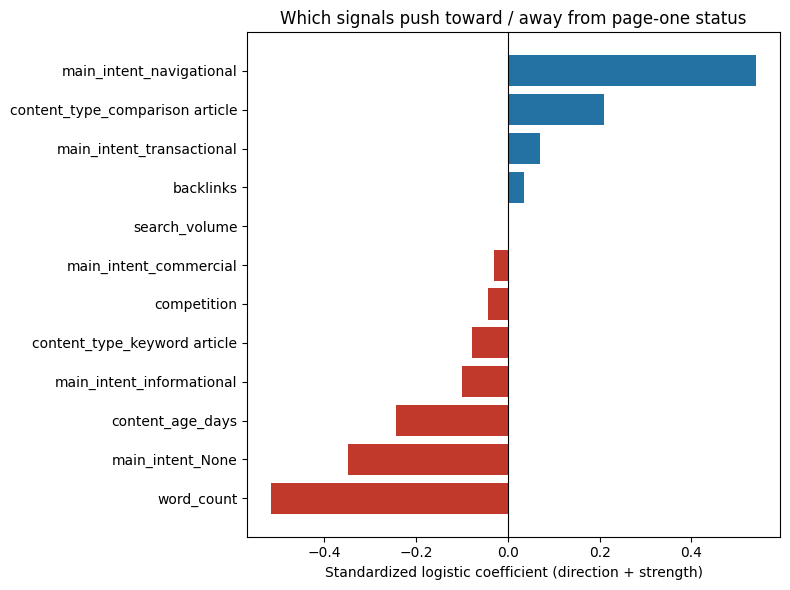

Saved chart to work/outputs/figures/signal_importance.png


In [9]:
# 2) Signal-importance chart -- standardized logistic coefficients, signed and ranked
feature_names = (NUM_FEATURES +
                  list(model.named_steps["pre"].named_transformers_["cat"]
                       .named_steps["onehot"].get_feature_names_out(CAT_FEATURES)))
coefs = pd.Series(model.named_steps["clf"].coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c0392b" if v < 0 else "#2471a3" for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors)
ax.set_xlabel("Standardized logistic coefficient (direction + strength)")
ax.set_title("Which signals push toward / away from page-one status")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("work/outputs/figures/signal_importance.png", dpi=150)
plt.show()

print("Saved chart to work/outputs/figures/signal_importance.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.